# Big Mart Sales Prediction Using Machine Learning

This project predicts `Item_Outlet_Sales` for the Big Mart Sales dataset using three basic regression algorithms: **Random Forest Regressor**, **XGBoost Regressor**, and **Gradient Boosting Regressor**.

The goal of this notebook is to practice the complete Machine Learning workflow — loading data, cleaning it, encoding it, training models, and comparing their performance — rather than getting a perfect score.

## Loading the Dataset

We first load the dataset and look at a few rows to understand what kind of data we are working with.

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\satya\Downloads\archive\train.csv")
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [243]:
df['Outlet_Type'].unique()

<StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str

## Dataset Inspection

Before doing anything else, it's a good idea to check the shape of the data, the data types, and some basic statistics. This helps us understand what we're dealing with and spot any obvious issues early on.

In [244]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [245]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


## Handling Missing Values

Now let's check if there are any missing values in the dataset.

In [246]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

### Missing Values Visualization

- This plot shows how many missing values are present in each column.
- It helps identify columns that need data cleaning.
- Columns with larger bars need more attention during preprocessing.
- If no bars show up, it means the dataset has no missing values at all.

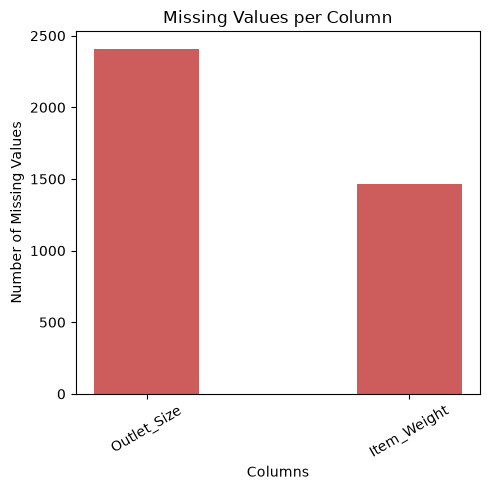

In [247]:
plt.figure(figsize=(5, 5))
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
plt.bar(null_counts.index, null_counts.values,width=0.4, color='indianred')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

We can see that `Item_Weight` and `Outlet_Size` have missing values. Numerical missing values are filled using the median, while categorical missing values are filled using the most common value (mode).

In [248]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# double check that there are no missing values left
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Let's also check if there are any duplicate rows in the dataset and remove them if needed.

In [249]:
df.duplicated().sum()
df = df.drop_duplicates()
df.shape

(8523, 12)

-> Now we separate the dataset into features and target.
-> `X` contains all the input columns the model will use to learn.
-> `y` contains `Item_Outlet_Sales`, which is the value we actually want to predict.
-> Since the target variable has larger values we are applying log transformation so that, model can be trained more effectively.

In [250]:
X = df.drop(columns=['Item_Outlet_Sales'])
y = np.log1p(df['Item_Outlet_Sales'])

## Encoding Categorical Variables

Machine Learning models need numbers as input, so we need to find out which columns are categorical (text) so we can convert them later. Different categorical columns actually need different treatment, so let's look at what we're working with before deciding how to handle each one.

In [251]:
categorical_columns = X.select_dtypes(include=['object']).columns
categorical_columns

C:\Users\satya\AppData\Local\Temp\ipykernel_14412\704806879.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object']).columns


Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='str')

In [252]:
numerical_columns = X.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='str')

Before encoding anything, let's look closer at `Item_Fat_Content`. It has values like `'Low Fat'`, `'low fat'`, and `'LF'` which all mean the same thing, just written differently. If we encode this column as it is, the model will treat these as different categories, which is wrong. So we fix this first using a simple dictionary mapping.

In [253]:
X['Item_Fat_Content'].unique()

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [254]:
fat_content_map = {
    'Low Fat': 'Low Fat',
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'Regular': 'Regular',
    'reg': 'Regular'
}

X['Item_Fat_Content'] = X['Item_Fat_Content'].map(fat_content_map)
X['Item_Fat_Content'].unique()

<StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str

Now that there are only two clean categories left (`Low Fat` and `Regular`), we can encode this column with `LabelEncoder`.

In [255]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Item_Fat_Content'] = le.fit_transform(X['Item_Fat_Content'])
X['Item_Fat_Content'].unique()

array([0, 1])

Next, let's look at `Outlet_Identifier`. Its values look like `OUT049`, `OUT018`, `OUT010`, etc. Instead of encoding the whole string with `LabelEncoder`, we can simply take the numeric part at the end of the string using `[3:]`, since the first three characters (`OUT`) are the same for every row and carry no information.

In [256]:
X['Outlet_Identifier'] = X['Outlet_Identifier'].str[3:].astype(int)
X['Outlet_Identifier'].unique()

array([49, 18, 10, 13, 27, 45, 17, 46, 35, 19])

`Outlet_Location_Type` has values like `Tier 1`, `Tier 2`, and `Tier 3`. These already have a natural numeric order, so instead of using `LabelEncoder` on the whole column, we can just extract the last character (the tier number) directly.

In [257]:
X['Outlet_Location_Type'] = X['Outlet_Location_Type'].str[-1].astype(int)
X['Outlet_Location_Type'].unique()

array([1, 3, 2])

`Outlet_Establishment_Year` on its own (like 1985 or 2009) isn't very meaningful to a model. What actually matters is how old the outlet is. So instead of using the year directly, we convert it into `Outlet_Age` by subtracting it from a reference year.

Note: To compute the outlet_age we have to reduce the establishment_year from 2013 since, it is the reference year.

In [258]:
X['Outlet_Age'] = 2013 - X['Outlet_Establishment_Year']
X = X.drop(columns=['Outlet_Establishment_Year'])
X[['Outlet_Age']].head()

,Outlet_Age
0,14
1,4
2,14
3,15
4,26


The remaining categorical columns — `Item_Identifier`, `Item_Type`, `Outlet_Size`, and `Outlet_Type` — don't have the same kind of pattern we exploited above, so for these we go ahead with the simple `LabelEncoder` approach.

In [259]:
remaining_categorical_columns = X.select_dtypes(include=['object']).columns
remaining_categorical_columns

C:\Users\satya\AppData\Local\Temp\ipykernel_14412\4286371532.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_categorical_columns = X.select_dtypes(include=['object']).columns


Index(['Item_Identifier', 'Item_Type', 'Outlet_Size', 'Outlet_Type'], dtype='str')

In [260]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in remaining_categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

Let's confirm that all the categorical columns have now been converted into numbers.

In [261]:
X.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age
0,156,9.30,0,0.016047,4,249.8092,49,1,1,1,14
1,8,5.92,1,0.019278,14,48.2692,18,1,3,2,4
2,662,17.50,0,0.016760,10,141.6180,49,1,1,1,14
3,1121,19.20,1,0.000000,6,182.0950,10,1,3,0,15
4,1297,8.93,0,0.000000,9,53.8614,13,0,3,1,26


In [262]:
print("Data types of features after encoding:")
X.dtypes

Data types of features after encoding:


Item_Identifier           int64
Item_Weight             float64
Item_Fat_Content          int64
Item_Visibility         float64
Item_Type                 int64
Item_MRP                float64
Outlet_Identifier         int64
Outlet_Size               int64
Outlet_Location_Type      int64
Outlet_Type               int64
Outlet_Age                int64
dtype: object

In [263]:
revised_df = pd.concat([X, y], axis=1)
revised_df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Outlet_Sales
0,156,9.300,0,0.016047,4,249.8092,49,1,1,1,14,8.225808
1,8,5.920,1,0.019278,14,48.2692,18,1,3,2,4,6.096776
2,662,17.500,0,0.016760,10,141.6180,49,1,1,1,14,7.648868
3,1121,19.200,1,0.000000,6,182.0950,10,1,3,0,15,6.597664
4,1297,8.930,0,0.000000,9,53.8614,13,0,3,1,26,6.903451
5,758,10.395,1,0.000000,0,51.4008,18,1,3,2,4,6.323658
6,696,13.650,1,0.012741,13,57.6588,13,0,3,1,26,5.842247
7,738,12.600,0,0.127470,13,107.7622,27,1,3,3,28,8.299973
8,440,16.200,1,0.016687,5,96.9726,45,1,2,1,11,6.982490
9,990,19.200,1,0.094450,5,187.8214,17,1,2,1,6,8.457769


In [264]:
X['Item_Type'].unique()

array([ 4, 14, 10,  6,  9,  0, 13,  5,  2,  8,  7,  3,  1, 15, 11, 12])

## Correlation Heatmap

- The heatmap below is just a visual version of the correlation table above.
- Darker/warmer colors show a strong positive relationship, while darker/cooler colors show a strong negative relationship.
- This makes it much quicker to spot which features are worth paying attention to compared to scanning a table of numbers.

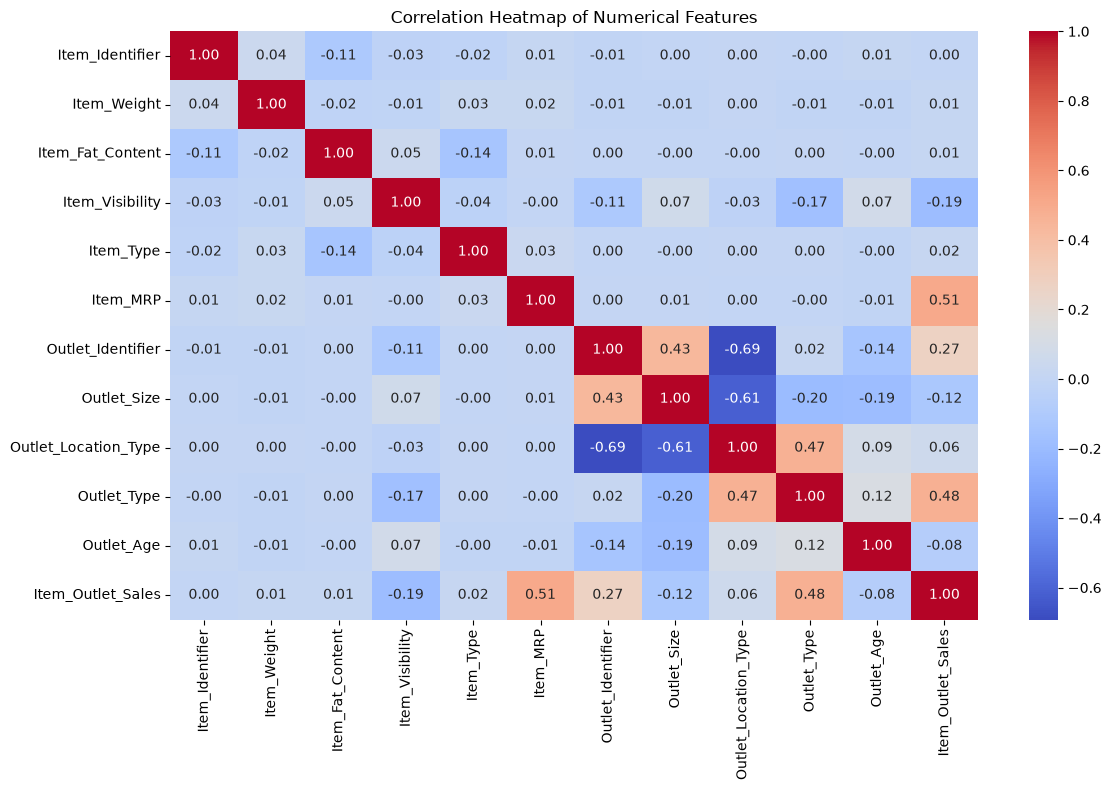

In [265]:
import seaborn as sns

correlation_matrix = pd.concat([X, y], axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Target Variable Analysis

- Here we rank every feature by how strongly it is correlated with `Item_Outlet_Sales`.
- The features with the highest absolute correlation are the ones most likely to matter to our models.
- We then plot these top features against the target so we can visually see the relationship, not just a number.

In [266]:
target_corr = correlation_matrix['Item_Outlet_Sales'].drop('Item_Outlet_Sales')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
top_features = target_corr_sorted.head(2).index.tolist()

print("Top correlated features with Item_Outlet_Sales:")

target_corr_sorted.head(2)

Top correlated features with Item_Outlet_Sales:


Item_MRP       0.509886
Outlet_Type    0.476722
Name: Item_Outlet_Sales, dtype: float64

Now let us plot the target variable against the top 2 correlated features. they are:
-> Item_MRP  VS  Outlet_sales
-> Item_Visibility  VS  Outlet_sales

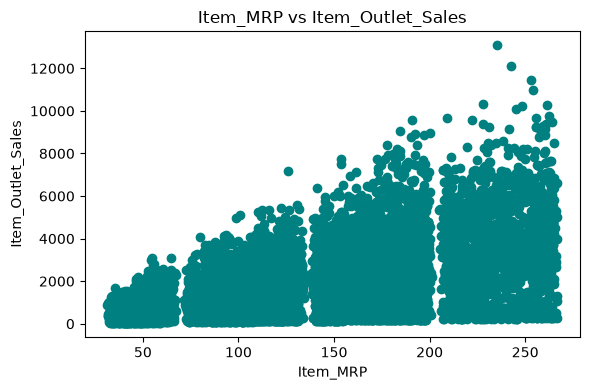

In [267]:
plt.figure(figsize=(6, 4))

plt.scatter(
    df['Item_MRP'],
    df['Item_Outlet_Sales'],
    color='teal'
)

plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.title('Item_MRP vs Item_Outlet_Sales')

plt.tight_layout()
plt.show()

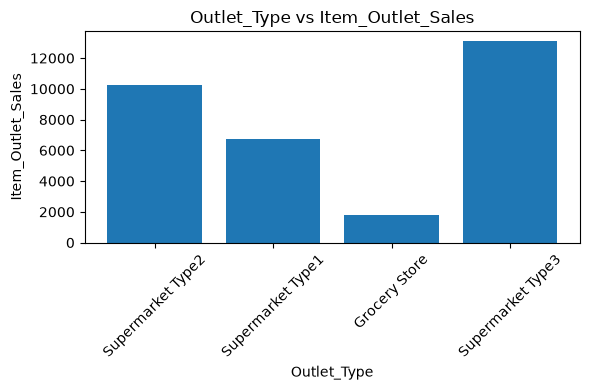

In [268]:
plt.figure(figsize=(6, 4))

outlet_names = [
    'Grocery Store',
    'Supermarket Type1',
    'Supermarket Type2',
    'Supermarket Type3'
]

plt.bar(df['Outlet_Type'], df['Item_Outlet_Sales'])

plt.xticks([2, 1, 0, 3], outlet_names, rotation=45)

plt.xlabel('Outlet_Type')

plt.ylabel('Item_Outlet_Sales')
plt.title('Outlet_Type vs Item_Outlet_Sales')

plt.tight_layout()
plt.show()

## Train-Test Split

We keep 80% of the data for training and 20% for testing. The model learns from the training data and is evaluated on unseen test data, which gives us a fair idea of how well it might perform in the real world.

In [269]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6818
Testing samples: 1705


## Model Training and Evaluation

## Model 1 — Random Forest Regressor

Random Forest builds many decision trees and averages their results, which usually makes it a solid and stable model to start with. We'll keep the settings simple and not tune it.

In [270]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

With the model trained, let's use it to make predictions on the test data.
To check how good the predictions are, we use two common metrics:
- **R2 Score** tells us how much of the variation in sales the model is able to explain (closer to 1 is better).
- **MSE (Mean Squared Error)** tells us the average squared difference between actual and predicted sales (lower is better).

In [271]:
from sklearn.metrics import r2_score, mean_squared_error


rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)
print("Random Forest MSE:", rf_mse)

Random Forest R2 Score: 0.718236861740752
Random Forest MSE: 0.296230011243982


## Model 2 — XGBoost Regressor

XGBoost is a boosting-based model that builds trees one after another, where each new tree tries to correct the mistakes of the previous ones. We'll use it with basic settings and no tuning.

In [272]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)

#Training the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Now we use the trained model to predict sales on the test data.
Evaluation:
 The above model is evaluated using r2_score and Mean Squared Error(MSE)

In [273]:
from sklearn.metrics import r2_score, mean_squared_error

xgb_pred = xgb_model.predict(X_test)

# Evaluating the model
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)

print("XGBoost R2 Score:", xgb_r2)
print("XGBoost MSE:", xgb_mse)

XGBoost R2 Score: 0.7076404729962354
XGBoost MSE: 0.30737046196555795


## Model 3 — Gradient Boosting Regressor

Gradient Boosting is similar in idea to XGBoost — it also builds trees sequentially to correct previous errors — but it's a simpler, classic implementation from scikit-learn.

In [274]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

Now let's generate predictions using the Gradient Boosting model.

In [275]:
from sklearn.metrics import r2_score, mean_squared_error

gb_pred = gb_model.predict(X_test)

#Evaluating the model
gb_r2 = r2_score(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)

print("Gradient Boosting R2 Score:", gb_r2)
print("Gradient Boosting MSE:", gb_mse)

Gradient Boosting R2 Score: 0.7434750703493411
Gradient Boosting MSE: 0.26969596968663173


## Model Comparison

Let's put all three models' results together in one table so it's easy to compare them side by side.

In [276]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'Gradient Boosting'
    ],
    'R2 Score': [
        rf_r2,
        xgb_r2,
        gb_r2
    ],
    'MSE': [
        rf_mse,
        xgb_mse,
        gb_mse
    ]
})

results

,Model,R2 Score,MSE
0,Random Forest,0.718237,0.296230
1,XGBoost,0.707640,0.307370
2,Gradient Boosting,0.743475,0.269696


A simple bar chart makes it easier to visually compare the R2 scores of the three models.

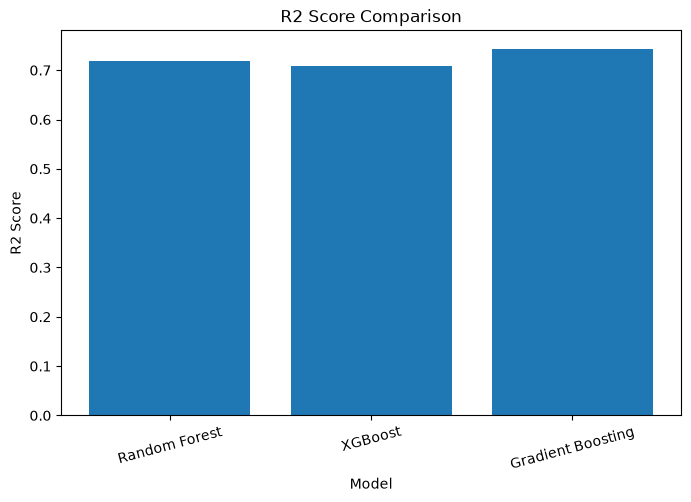

In [277]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['R2 Score'])
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison')
plt.xticks(rotation=15)
plt.show()

Let's do the same for the MSE values.

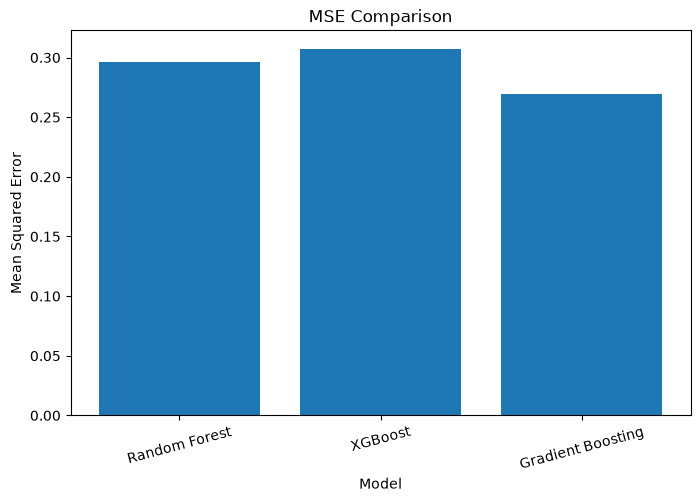

In [278]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['MSE'])
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.title('MSE Comparison')
plt.xticks(rotation=15)
plt.show()

## Final Conclusion

The three regression models — Random Forest, XGBoost, and Gradient Boosting — were successfully trained and evaluated on the Big Mart Sales dataset. Looking at the comparison table and charts above, the model with the higher R² score and lower MSE can be considered the better performer for this dataset.

The results may not be perfect, and that's okay — the main purpose of this project was to understand and practice the complete Machine Learning workflow: loading data, handling missing values, encoding categorical columns, splitting into train/test sets, training multiple models, and evaluating and comparing them.